# Mask

## Learning Outcome

1. Find histogram of the region of interest using the image mask.
2. Apply Image Mask in binary image.
3. Bitwise operation in the binary images.


In this recipe, you will learn how to work with binary images, including how to apply binary element-wise operations.

## Image masks and binary operations

You have already learned about histogram. Suppose let's say you want a histogram of Image on some region only.



<image>
<center>
<!-- <img src="https://drive.google.com/uc?export=view&id=1sOCxub8QGAERfGbxbqlzlrFI0uZmDaqi"/> -->
<img src ="https://i.postimg.cc/SxKRLv4m/image.png"/>
<Figcaption>Figure 1: Image with region of interest </Figcaption>
</center>
</image>



In the above figure, the Red rectangle shows a region of interest, i.e., the region you want to find histogram. In the following section, I will explain how to find a histogram of the region of interest.

__Step 1:__

1. Create a binary Image with white color in a region you want to find histogram and set rest value zero. This binary Image is called Mask.

<image>
<center>
<!-- <img src="https://drive.google.com/uc?export=view&id=1MPCIfv2esTafqzlj-ngcM7Hwaljgzhc5"/> -->
<img src ="https://i.postimg.cc/VNjxJzhv/image.png"/>
<Figcaption>Figure 2: Mask </Figcaption>
</center>
</image>

In our problem,

The binary mask defines a region of interest in the original image. Here in this diagram, Our region of interest is that flower inside a red rectangle.
* Mask pixel values of 1 indicate the image pixel belongs to a region of interest.
* Mask pixel values of 0 indicate the image pixel is part of the background.

Then In the given image, black color is part of the background, while white color indicates a region of interest.


__Step 2:__
2. Apply this mask on original Image(Bitwise AND) to get masked image.




<image>
<center>
<!-- <img src="https://drive.google.com/uc?export=view&id=1ZvCzV_A1nqK1bs9JG-2r165zKXb84OcD"/> -->
<img src="https://i.postimg.cc/Jzj6qP5d/image.png"/>
<Figcaption>Figure 3: Masked Image</Figcaption>
</center>
</image>

Image masking involves adding some other photo to the original image as a mask or adjusting the pixel values in the image.


**Step 3:**
3. Plot the masked image histogram.

<image>
<center>
<!-- <img src="https://drive.google.com/uc?export=view&id=1_nuVqfPr4-ebnIZwslFqoW47gNkmxR3d"/> -->
<img src='https://i.postimg.cc/4xvPtnXD/image.png'/>
<Figcaption>Figure 4: Masked Image Histogram</Figcaption>
</center>
</image>


You can compare the result of the overall steps.



<image>
<center>
<!-- <img src="https://drive.google.com/uc?export=view&id=18oVsPeJ8x18rDqJptiEU1n4zHWfF5NoM"/> -->
<img src="https://i.postimg.cc/1XH6XVGB/image.png"/>
<Figcaption>Figure 5: Image masking steps </Figcaption>
</center>
</image>

Let's write a code to do exactly the same steps.

In [1]:
!wget --no-check-certificate 'https://www.publicdomainpictures.net/pictures/20000/velka/bush-roses-117101295939187IVE.jpg' -O flower.jpg

--2025-08-13 13:58:18--  https://www.publicdomainpictures.net/pictures/20000/velka/bush-roses-117101295939187IVE.jpg
Resolving www.publicdomainpictures.net (www.publicdomainpictures.net)... 2606:4700:10::ac42:8c37, 2606:4700:10::ac42:863c, 172.66.134.60, ...
Connecting to www.publicdomainpictures.net (www.publicdomainpictures.net)|2606:4700:10::ac42:8c37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 277649 (271K) [image/jpeg]
Saving to: ‘flower.jpg’

flower.jpg          100%[===================>] 271.14K  --.-KB/s    in 0.03s   

2025-08-13 13:58:19 (9.11 MB/s) - ‘flower.jpg’ saved [277649/277649]



Read the image.

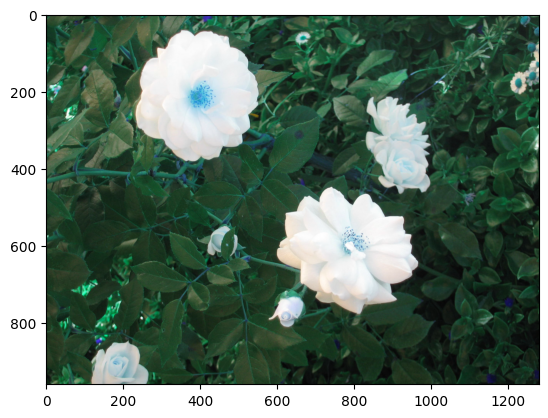

In [2]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('flower.jpg')
plt.imshow(img)

As shown in `figure 5`, we want to isolate the flower and then find histogram of the isolated image.

First let me show you how you can plot the red rectangle on the image.  

I will copy the image on `annoted_image` variable becase plotting shapes on image changes orginal image.

In [4]:
annoted_image = img.copy()

In OpenCV you can draw a rectangle on the image using [cv2.rectangle()](https://docs.opencv.org/master/dc/da5/tutorial_py_drawing_functions.html).

You will need two points to plot the rectangle.  
* Top-left corner  
    * In our problem top left corner is 210 on the x-axis and 30 on the y-axis. So the coordinate is (210,30).
* Bottom-right corner:
     * In our problem bottom right corner is 570 on the x-axis and 410 on the y-axis. So the coordinate is (570,410).

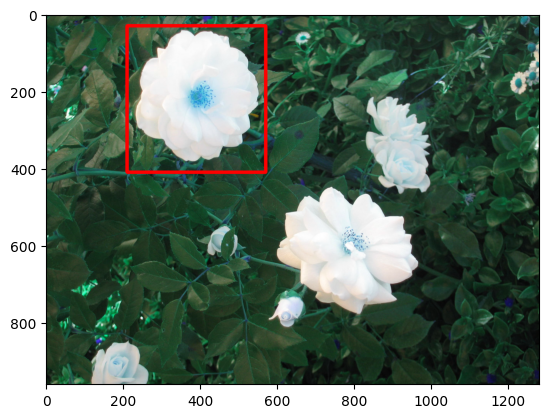

In [5]:
cv2.rectangle(annoted_image, pt1=(210,30),  pt2=(570,410),color= (255,0,0), thickness=8)
plt.imshow(annoted_image)
plt.savefig('anootflower.png')

Let's create a Mask.

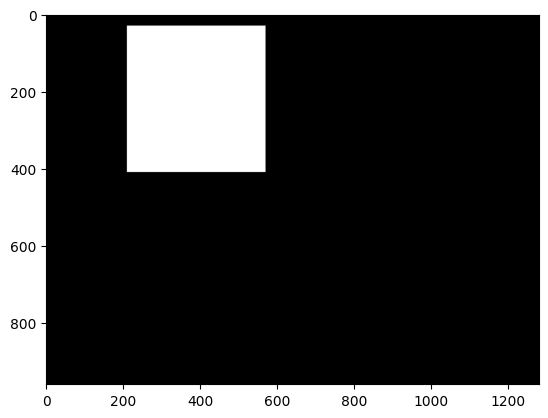

In [6]:
import numpy as np
mask = np.zeros(img.shape[:2], np.uint8)
mask[30:410, 210:570] = 255
plt.imshow(mask, cmap='gray')
plt.savefig('mask_flower.png')

It's useful to represent binary images—images containing only black and white pixels—
using np.uint8 arrays with only `0 and 255 values` correspondingly.

Plot Image, its mask and Masked Image along with their histogram.

In [7]:
min_val = 0
max_val = 256

In [8]:
masked_img = cv2.bitwise_and(img,img,mask = mask) # create a mask image
hist_full = cv2.calcHist([img],[min_val],None,[max_val],[min_val,max_val]) # hisogram of original image
hist_mask = cv2.calcHist([img],[min_val],mask,[max_val],[min_val,max_val]) # hisogram of masked image

Text(0.5, 0, 'Masked Image')

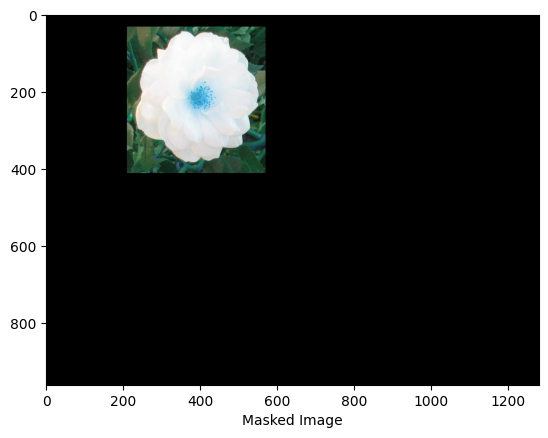

In [9]:
plt.imshow(masked_img)
plt.xlabel("Masked Image")

Text(0.5, 0, 'Masked Image histogram')

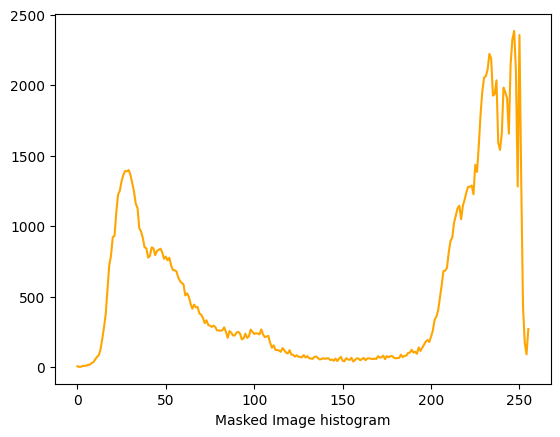

In [10]:
plt.plot(hist_mask,color='orange')
plt.xlabel("Masked Image histogram")

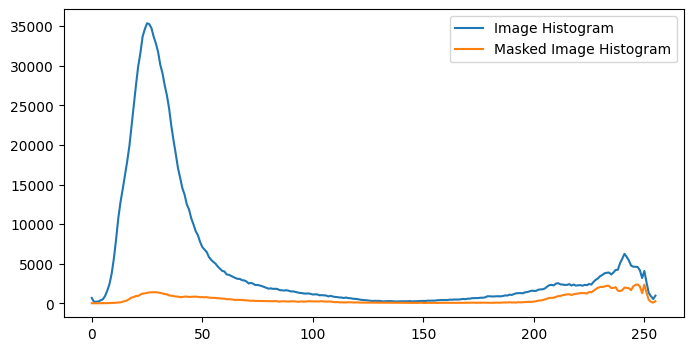

In [11]:
plt.figure(figsize=(8,4))
plt.plot(hist_full,label = "Image Histogram")
plt.plot(hist_mask, label='Masked Image Histogram')
plt.legend(loc="upper right")
plt.savefig('comparehist.png', dpi=500)
plt.show()

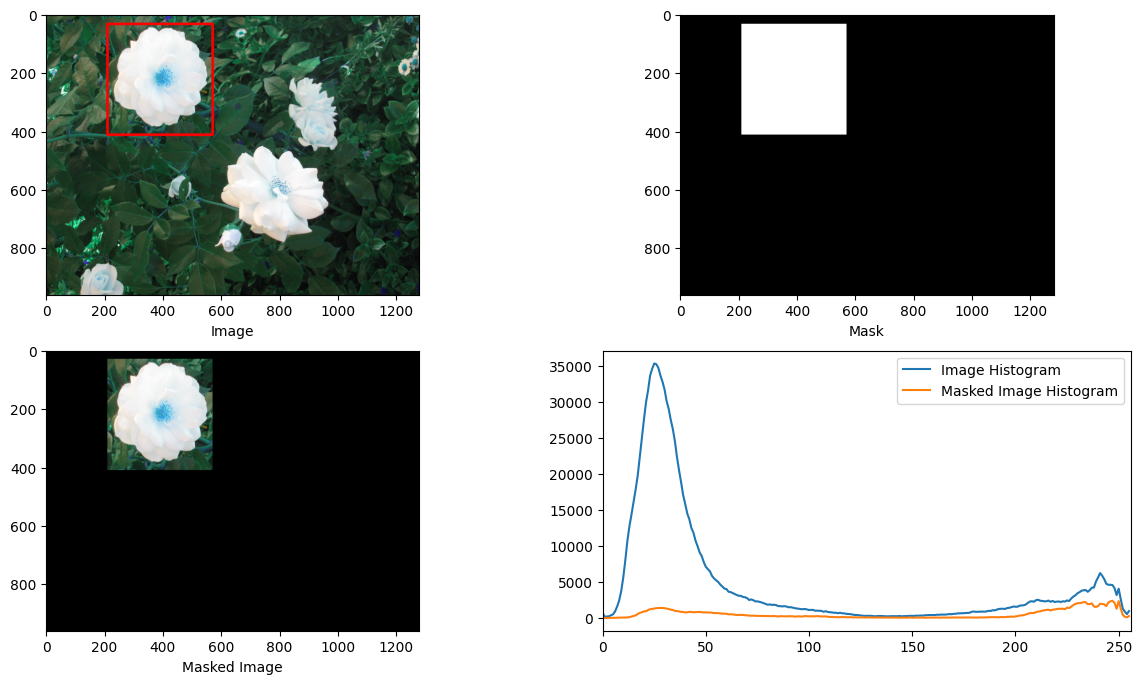

In [12]:
#@title Compare the results
plt.figure(figsize=(15,8))
plt.subplot(221), plt.imshow(annoted_image, cmap='gray'),plt.xlabel("Image")
plt.subplot(222), plt.imshow(mask,cmap='gray') ,plt.xlabel("Mask")
plt.subplot(223), plt.imshow(masked_img, cmap='gray') ,plt.xlabel("Masked Image")
plt.subplot(224), plt.plot(hist_full,label = "Image Histogram"), plt.plot(hist_mask, label='Masked Image Histogram'),plt.legend(loc="upper right")
plt.xlim([min_val,max_val])
# plt.savefig("mask_and_hist.png")
plt.show()

In the previous example, I've used a mask to focus only on the region of interest, i.e., flower using an arithmetic operator.

* One exciting application of this process is in the computer vision system to recognize faces. In face recognition problem The only part of the image we are interested in finding and describing is the parts of the image that contains faces. We can construct a mask to
show only the faces in the image, and don't care about
the rest of the image's content.

### Curious to Know what if you don't want a black background ?

* Apply logical OR operation on the background you want with the masked image to change the black background.

In [13]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=view&id=1J1FrThP6exZC_5AmOEJHTa49mRkjUQ3G' -O back.jpg

--2025-08-13 13:59:37--  https://drive.google.com/uc?export=view&id=1J1FrThP6exZC_5AmOEJHTa49mRkjUQ3G
Resolving drive.google.com (drive.google.com)... 2404:6800:4007:833::200e, 142.251.222.174
Connecting to drive.google.com (drive.google.com)|2404:6800:4007:833::200e|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1J1FrThP6exZC_5AmOEJHTa49mRkjUQ3G&export=view [following]
--2025-08-13 13:59:38--  https://drive.usercontent.google.com/download?id=1J1FrThP6exZC_5AmOEJHTa49mRkjUQ3G&export=view
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 2404:6800:4007:83b::2001, 172.217.24.1
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|2404:6800:4007:83b::2001|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1162 (1.1K) [image/png]
Saving to: ‘back.jpg’

back.jpg            100%[===================>]   1.13K  --.-KB/s    in 0s      

2025-08-1

Read the background image.

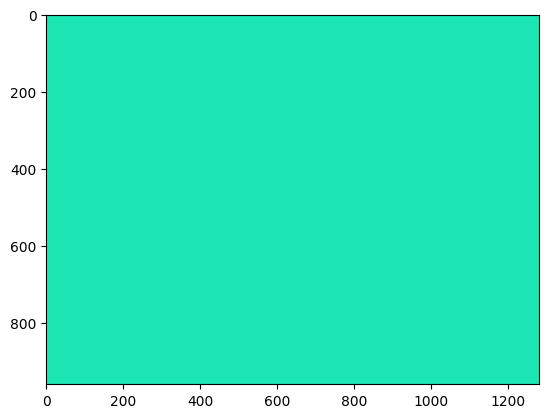

In [14]:
import cv2
import numpy as np
m1 = cv2.imread('back.jpg')
background = cv2.resize(m1,(1280,960))
plt.imshow(background)

Make a masked image.

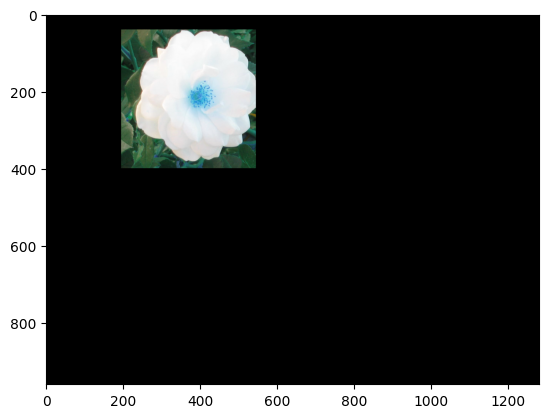

In [15]:
img = cv2.imread('flower.jpg',1)
mask = np.zeros(img.shape, np.uint8)
mask[40:400, 195:545] = 255
masked_image = cv2.bitwise_and(img, mask)
plt.imshow(masked_image)

Apply logical OR between masked image and background image.

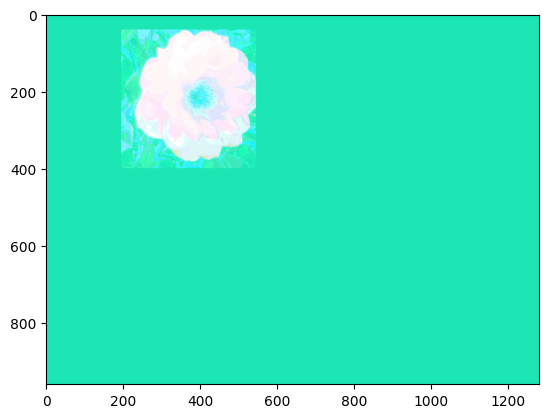

In [16]:
image_after_bitwise_or = background | masked_image
plt.imshow(image_after_bitwise_or)

[Text(0.5, 0, 'Image with changed background')]

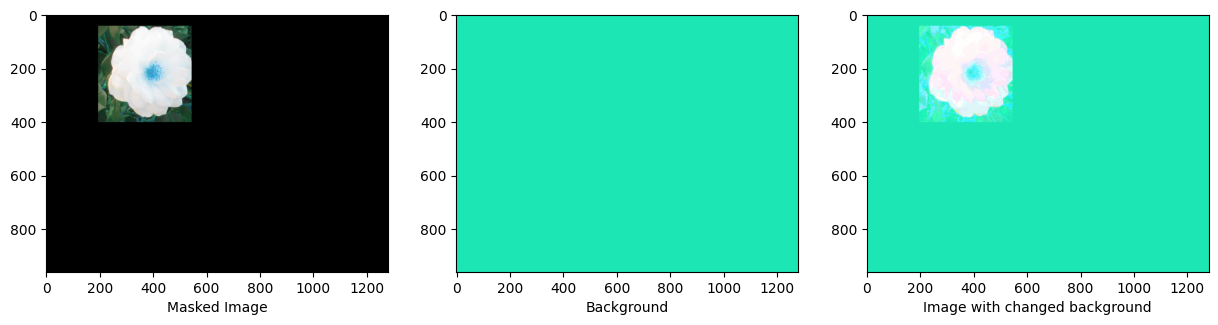

In [17]:
#@title Plot Results
f, axes = plt.subplots(1, 3, figsize=(15,10))
axes[0].imshow(masked_image, cmap='gray')
axes[1].imshow(background, cmap='gray')
axes[2].imshow(image_after_bitwise_or, cmap='gray')
plt.setp(axes[0], xlabel='Masked Image')
plt.setp(axes[1], xlabel='Background')
plt.setp(axes[2], xlabel='Image with changed background')

The black color of one Image is replaced. If you don't want a black background, then apply this method. You can apply other Logical operations according to your use case.

## Different Logical operation on Mask

You can find exciting regions by applying logical operations on different masks. Let's see some examples.

### Logical AND

Suppose you want to create a mask including an arc of the circle on the top left side. You can create this by applying logical AND operation.

<image>
<center>
<!-- <img src="https://drive.google.com/uc?export=view&id=1j25uSvML0eq7WzvFIIymdY3gdbYo0JBR"/> -->
<img src=" https://i.postimg.cc/wvSHNwVT/image.png"/>
<Figcaption>Figure 6: Image mask with arc </Figcaption>
</center>
</image>

__Example:__

_Create a synthetic binary image with a circle mask._

Define the shape of the mask with a circle.

In [ ]:
length=1000
breadth = 1000

Create a circle mask.

In [ ]:
circle_image = np.zeros((length, breadth), np.uint8) # zero is black

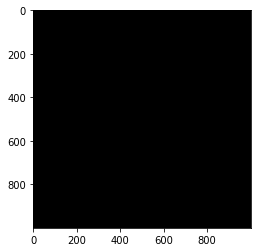

In [ ]:
plt.imshow(circle_image,cmap='gray')

_Let's make a circle inside this image, the circle has it's centre on `(500,500)` with the radius of `100`._

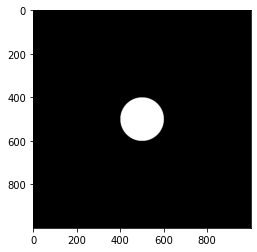

In [ ]:
centre = (500, 500)
radius = 100
cv2.circle(circle_image, centre, radius, 255, -1) # 1 is white
plt.imshow(circle_image,cmap='gray')

_Similarly make rectangle._

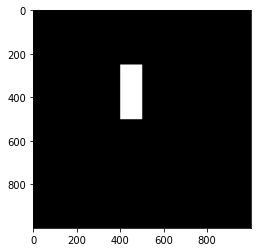

In [ ]:
rect_image = np.zeros((length, breadth), np.uint8)
# Start coordinate,
# represents the top left corner of rectangle
Start_coordinate = (400, 250)
# Ending coordinate,
# represents the bottom right corner of rectangle
Ending_coordinate = (500, 500)
cv2.rectangle(rect_image, Start_coordinate, Ending_coordinate, 255, -1) # make rectangle inside rect_image with white inside
plt.imshow(rect_image,cmap='gray')

Mask using Bitwise AND.

_Combine the circle and rectangle masks using a bitwise AND operator:_

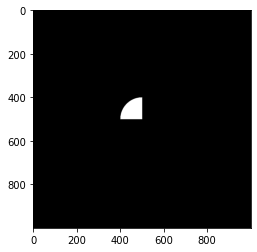

In [ ]:
# circle_and_rect_image = circle_image & rect_image
circle_and_rect_image = cv2.bitwise_and(circle_image,\
                                        rect_image,\
                                        mask = None)
plt.imshow(circle_and_rect_image, cmap='gray')

Truth Table

| A        | B           | A & B  |
| ------------- |:-------------:| -----:|
| 0     | 0 | 0 |
| 0      | 1     |  0|
| 1| 0      |   0 |
| 1| 1     |    1 |


<!-- <img src="https://drive.google.com/uc?export=view&id=1IL6-cl0J_jjSbcTf9zT26v-lNYGczkcK"/> -->




$$
    AND(x,y)=
\begin{cases}
    1,& \text{if both x and y are 1}\\
    0,              & \text{Otherwise}
\end{cases}
\
$$


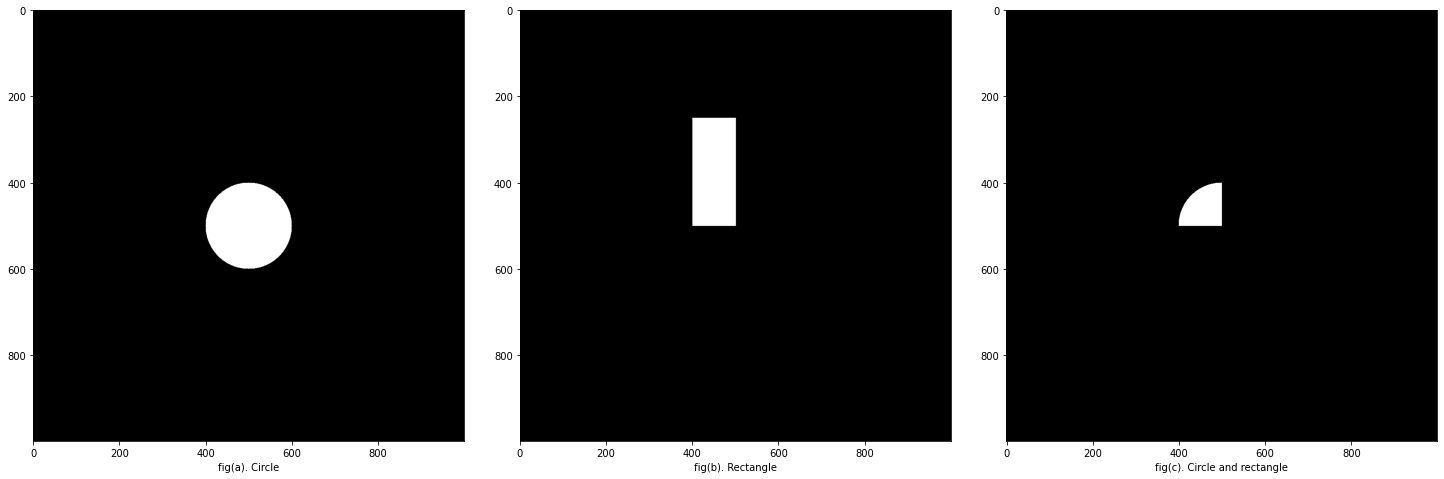

In [ ]:
#@title Plot Results
f, axes = plt.subplots(1, 3, figsize=(20,12))
axes[0].imshow(circle_image, cmap='gray')
axes[1].imshow(rect_image, cmap='gray')
axes[2].imshow(circle_and_rect_image, cmap='gray')
plt.setp(axes[0], xlabel='fig(a). Circle')
plt.setp(axes[1], xlabel='fig(b). Rectangle')
plt.setp(axes[2], xlabel='fig(c). Circle and rectangle')
plt.tight_layout(pad=0.5, h_pad=3, w_pad=3)
plt.savefig("logical_and_mask.png")


- _In the figure, you can make sense that Bitwise AND operation on two images results from a arc. It's because in Bitwise AND operation, if both values are 1(white), then the result is white. i.e., If one input is black, the output is black._

### Mask Using Bitwise OR

Suppose you want to create a mask with a `b` shaped structure. You can create this by applying logical OR operation.




_Combine the circle and rectangle masks using a bitwise OR operator_

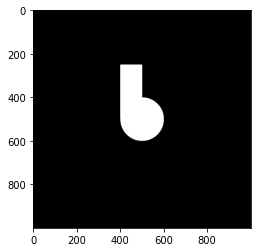

In [ ]:
#Combine the circle and rectangle masks using a bitwise OR operator:
circle_or_rect_image = circle_image | rect_image
plt.imshow(circle_or_rect_image,cmap='gray')

Truth Table:


| A        | B           | A $|$ B  |
| ------------- |:-------------:| -----:|
| 0     | 0 | 0 |
| 0      | 1     |  1 |
| 1| 0      |   1 |
| 1| 1     |    1 |

<!--

<img src="https://drive.google.com/uc?export=view&id=1yJx6oKQ5AcQzlhj2wDoQwXVXOJHumcPO"/> -->



$$
    OR(x,y)=
\begin{cases}
    1,& \text{if either x or y (or both x and y ) is 1}\\
    0,              & \text{Otherwise}
\end{cases}
\
$$


_Let's Visualize the results:_

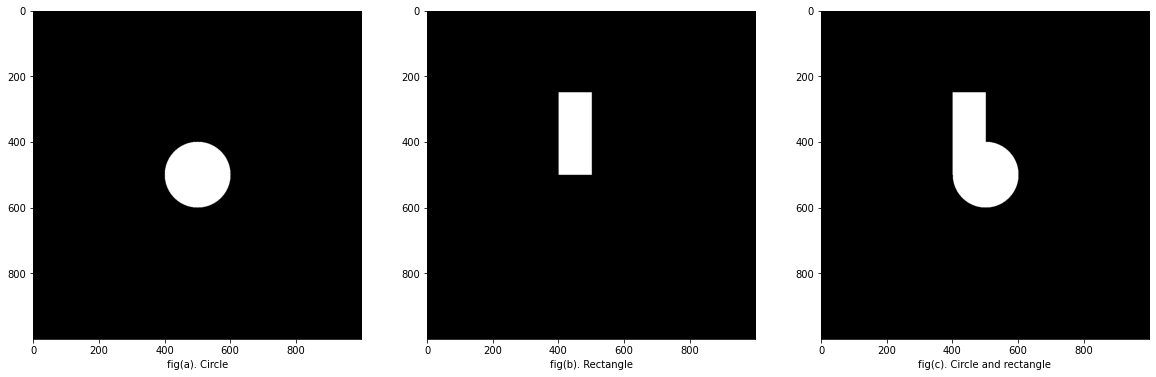

In [ ]:
#@title Plot Results
f, axes = plt.subplots(1, 3, figsize=(20,12))
axes[0].imshow(circle_image, cmap='gray')
axes[1].imshow(rect_image, cmap='gray')
axes[2].imshow(circle_or_rect_image, cmap='gray')
plt.setp(axes[0], xlabel='fig(a). Circle')
plt.setp(axes[1], xlabel='fig(b). Rectangle')
plt.setp(axes[2], xlabel='fig(c). Circle and rectangle')
# plt.tight_layout(pad=0.5, h_pad=3, w_pad=3)
plt.savefig("logical_or_mask.png")




- _In Bitwise OR operation, if any of the input is white(1), then output is white. i.e., If any of the data is black, then output is black. That is why you've got a `b` shaped mask._

Both OpenCV and NumPy support all
usual binary operators: `NOT, AND, OR, and XOR.` They are available through aliases, such as `~, &, |, ^,` as well as
through functions such as `cv2.bitwise_not/np.bitwise_not` and `cv2.bitwise_and/np.bitwise_and`.

## Key Take-Aways

- A mask is a binary image consisting of zero- and non-zero values.

- If a mask is applied to a grayscale image of the same size, all the black part of mask are set to zero in the output image. All others remain unchanged.


- You can apply bitwise operation on Mask.


$$
    AND(x,y)=
\begin{cases}
    1,& \text{if both x and y are 1}\\
    0,              & \text{Otherwise}
\end{cases}
\
$$






$$
    OR(x,y)=
\begin{cases}
    1,& \text{if either x or y (or both x and y ) is 1}\\
    0,              & \text{Otherwise}
\end{cases}
\
$$

## References

Szeliski, R. (2010). Computer vision: algorithms and applications. Springer Science & Business Media.

Gonzalez, R. C., Woods, R. E., & Eddins, S. L. (2004). Digital image processing using MATLAB. Pearson Education India.


